# LatentMind V6 — Colab Notebook

**Training-first pipeline**: synthesizes agentic traces → trains the policy brain → loads the agent → runs tests.

The brain is a trained 3-head MLP. It picks one action at a time — rag · sql · chart · email · template — and re-decides after each step, stopping when its *continue* score drops below the seuil.

Requires: T4 or L4 GPU runtime.

In [1]:
# ─── GPU CLEANUP — run this any time before re-running the agent cells ───────
# Releases all model weights from VRAM so you can reload without OOM.
# Safe to run even on the very first pass (does nothing if nothing is loaded).

import gc, sys, torch

def cleanup(verbose: bool = True, _globals: dict | None = None) -> None:
    freed: list[str] = []

    # ── 1. delete notebook-level globals that hold model references ───────
    # The `agent` object wraps the LangGraph graph; its node closures call
    # get_slm() / get_polisher() / get_brain() — keeping tensors alive even
    # after we null the module-level singletons. Kill it first.
    _g = _globals or {}
    for name in ("agent", "slm", "stt", "tts"):
        if name in _g:
            del _g[name]
            freed.append(f"global:{name}")

    # ── 2. SLM — main model + 0.5B drafter + polisher ─────────────────────
    try:
        import v6.slm as _m
        slm_obj = _m._slm
        if slm_obj is not None:
            for tid in list(slm_obj._store.keys()):
                slm_obj.clear_thread(tid)
            if hasattr(slm_obj, "_draft") and slm_obj._draft is not None:
                del slm_obj._draft        # 0.5B drafter
                slm_obj._draft = None
                slm_obj._draft_tokenizer = None
            if hasattr(slm_obj, "model"):
                del slm_obj.model         # main 3B / 7B weights
            _m._slm = None
            freed.append("SLM (main + drafter)")
        pol_obj = _m._polisher
        if pol_obj is not None:
            if hasattr(pol_obj, "model"):
                del pol_obj.model
            _m._polisher = None
            freed.append("polisher")
    except Exception:
        pass

    # ── 3. BGE-M3 encoder + retriever ─────────────────────────────────────
    try:
        import v6.knowledge as _m
        enc_obj = _m._encoder
        if enc_obj is not None:
            if hasattr(enc_obj, "model"):
                del enc_obj.model
            _m._encoder = None
            freed.append("BGE-M3")
        _m._retriever = None
    except Exception:
        pass

    # ── 4. brain head + schema ─────────────────────────────────────────────
    try:
        import v6.brain as _m
        if _m._brain is not None:
            _m._brain = None
            freed.append("brain head")
    except Exception:
        pass
    try:
        import v6.schema as _m
        _m._schema = None
    except Exception:
        pass

    # ── 5. speech models — STT (faster-whisper) + TTS (XTTS-v2) ───────────
    try:
        import v6.speech as _m
        if _m._stt is not None:
            if hasattr(_m._stt, "model"):
                del _m._stt.model
            _m._stt = None
            freed.append("STT (faster-whisper)")
        if _m._tts is not None:
            if hasattr(_m._tts, "xtts"):
                del _m._tts.xtts
            _m._tts = None
            freed.append("TTS (XTTS-v2)")
    except Exception:
        pass

    # ── 6. garbage-collect (multiple passes to break cycles) ──────────────
    for _ in range(3):
        gc.collect()

    # ── 7. release CUDA allocator cache ───────────────────────────────────
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

    if verbose:
        if freed:
            print("Released:", ", ".join(freed))
        else:
            print("Nothing was loaded — nothing to release")
        if torch.cuda.is_available():
            alloc = torch.cuda.memory_allocated() / 1e9
            total = torch.cuda.get_device_properties(0).total_memory / 1e9
            print(f"VRAM: {alloc:.2f} GB / {total:.1f} GB after cleanup")
        print("Ready to re-run the load cell.")

cleanup(verbose=True, _globals=globals())


Nothing was loaded — nothing to release
VRAM: 0.00 GB / 23.7 GB after cleanup
Ready to re-run the load cell.


In [2]:
# Core inference + RAG
!pip install 'transformers>=4.46.0' 'sentence-transformers>=3.0.0' 'accelerate>=0.27.0'
print("✓ transformers, sentence-transformers, accelerate")

# Graph + math
!pip install 'langgraph>=0.2.0' 'bitsandbytes>=0.43.0' scipy matplotlib
print("✓ langgraph, bitsandbytes, scipy, matplotlib")

# Utils
!pip install jinja2 pydantic pymysql mysql-connector-python
print("✓ jinja2, pydantic, mysql connectors")

print("\n✓ Setup complete! Ready to load agent.")

✓ transformers, sentence-transformers, accelerate
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 51.7 MB/s eta 0:00:00:00:0100:01
✓ langgraph, bitsandbytes, scipy, matplotlib
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.7/45.7 kB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.7/21.7 MB 123.8 MB/s eta 0:00:0000:0100:01
✓ jinja2, pydantic, mysql connectors

✓ Setup complete! Ready to load agent.


In [3]:
# Voice layer — STT (faster-whisper) + TTS (Coqui XTTS-v2) + transcript fixup
# faster-whisper = CTranslate2 Whisper large-v3 (transcription)
# coqui-tts      = maintained XTTS-v2 fork (PyPI name is `coqui-tts`, not `TTS`)
# rapidfuzz      = fuzzy-correct wilaya names + KPI acronyms in the transcript
!pip install -q faster-whisper soundfile rapidfuzz
!pip install -q coqui-tts
# coqui-tts can pin an older transformers — re-assert ours so the SLM still loads
!pip install -q 'transformers>=4.46.0'
print("✓ faster-whisper, coqui-tts, soundfile, rapidfuzz (voice layer ready)")
print("  If transformers was changed above, do Runtime → Restart, then re-run from here.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 60.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 126.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 36.3/36.3 MB 76.7 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 39.0/39.0 MB 60.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 130.7 MB/s eta 0:00:0000:0100:01
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 862.8/862.8 kB 53.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 36.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.2/56.2 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 997.3/997.3 kB 77.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 648.4/648.4 kB 52.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.5/163.5 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.1/71

In [4]:
from google.colab import drive
drive.mount('/content/drive')

import os, subprocess, sys, shutil

REPO_URL = 'https://github.com/Hamza09Hamza/Latent-Djezzy.git'
REPO_DIR = '/content/Latent-Djezzy'
BRANCH   = 'main'

os.chdir('/content')

if os.path.isdir(os.path.join(REPO_DIR, '.git')):
    # Repo already present — pull latest without nuking trained models
    print(f'Repo found — pulling latest from origin/{BRANCH} ...')
    subprocess.run(['git', '-C', REPO_DIR, 'fetch', 'origin'], check=True)
    subprocess.run(['git', '-C', REPO_DIR, 'checkout', '-B', BRANCH, f'origin/{BRANCH}'], check=True)
    print(f'✓ repo updated to latest origin/{BRANCH}')
else:
    if os.path.isdir(REPO_DIR):
        shutil.rmtree(REPO_DIR)
        print('removed stale directory')
    subprocess.run(
        ['git', 'clone', '--depth=1', '--branch', BRANCH, REPO_URL, REPO_DIR],
        check=True)
    print(f'✓ cloned {BRANCH} → {REPO_DIR}')

# Flush any cached v6 modules so the freshly pulled code is picked up
for mod in list(sys.modules.keys()):
    if 'v6' in mod:
        del sys.modules[mod]

os.chdir(REPO_DIR)

# Show the exact commit so you can confirm you're on the latest
commit = subprocess.check_output(
    ['git', 'log', '--oneline', '-1'], cwd=REPO_DIR).decode().strip()
print(f'HEAD: {commit}')

head_path = 'models/brain_head.pt'
if os.path.isfile(head_path):
    size_mb = os.path.getsize(head_path) / 1e6
    print(f'✓ Trained brain head found ({size_mb:.1f} MB) — will skip training')
else:
    print('! Trained brain head NOT found — Cells 6-7 will build it (~2 min on T4)')

Mounted at /content/drive
✓ cloned main → /content/Latent-Djezzy
HEAD: 09b92e9 Fix benchmark: add run_voice_benchmark and wire audio files into inference
! Trained brain head NOT found — Cells 6-7 will build it (~2 min on T4)


In [5]:
import shutil, os

# Database location — checks LatentDjezzy folder first, falls back to MyDrive root
LOCAL_DB   = "/content/interndb.sqlite"

possible_locations = [
    "/content/drive/MyDrive/LatentDjezzy/interndb.sqlite",
    "/content/drive/MyDrive/interndb.sqlite",
]

DRIVE_DB = None
for loc in possible_locations:
    if os.path.isfile(loc):
        DRIVE_DB = loc
        break

if not DRIVE_DB:
    print("⚠ Database not found in:")
    for loc in possible_locations:
        print(f"    {loc}")
    print("\nPlease ensure interndb.sqlite is in /MyDrive/LatentDjezzy/ or /MyDrive/")
else:
    if not os.path.isfile(LOCAL_DB):
        shutil.copy(DRIVE_DB, LOCAL_DB)
        print(f"✓ copied {os.path.getsize(LOCAL_DB):,} bytes → {LOCAL_DB}")
    else:
        print("✓ SQLite already present:", LOCAL_DB)

# Create output dirs on Drive so charts, emails, reports and audio are persisted
output_base = "/content/drive/MyDrive/LatentDjezzy/v6_output"
for d in [
    f"{output_base}/charts",
    f"{output_base}/emails",
    f"{output_base}/reports",
    f"{output_base}/audio",      # benchmark audio fixtures + TTS outputs
]:
    os.makedirs(d, exist_ok=True)
print(f"✓ Output dirs ready on Drive → {output_base}/")

✓ copied 40,271,872 bytes → /content/interndb.sqlite
✓ Output dirs ready on Drive → /content/drive/MyDrive/LatentDjezzy/v6_output/


In [6]:
import os, warnings, logging

warnings.filterwarnings("ignore")
logging.getLogger("transformers").setLevel(logging.ERROR)
os.environ["TRANSFORMERS_VERBOSITY"] = "error"

os.environ["V6_USE_SQLITE"]    = "1"
os.environ["V6_SQLITE_PATH"]   = "/content/interndb.sqlite"

# ── SQL generator model size ──────────────────────────────────────────────
# "3b"  → Qwen2.5-Coder-3B-Instruct     (~6.4 GB fp16)  — safe baseline
# "4b"  → Qwen3-4B-Instruct-2507        (~8.0 GB fp16)  ← current default
#          text-only, native Instruct, 262K ctx, no thinking mode.
#          drafter = Qwen3-0.6B (shared tokenizer, 2-4x speed)
# "7b"  → Qwen2.5-Coder-7B-Instruct     (~14 GB fp16)   — needs V6_4BIT=1
#
# Note: Qwen3.5-4B is the multimodal branch (vision+text) — model_type
# `qwen3_5` only ships in transformers from git main and there's no
# Instruct head. Stock Colab transformers can't load it. We use the
# pure-text Qwen3-4B-Instruct-2507 instead (transformers >= 4.51 OK).
os.environ["V6_SLM_SIZE"]       = "4b"

os.environ["V6_4BIT"]           = "0"   # "1" only needed for 7B on 16 GB T4
os.environ["V6_SPECULATIVE"]    = "1"   # drafter → 2-4x speed
os.environ["V6_CONSTRAINED_SQL"] = "0"

os.environ["V6_POLISHER_HUB_ID"] = "Qwen/Qwen2.5-1.5B-Instruct"
os.environ["V6_SLM_OVERRIDE"]   = ""
os.environ["V6_OUTPUT_DIR"]     = "/content/drive/MyDrive/LatentDjezzy/v6_output"
os.environ["PYTORCH_ALLOC_CONF"] = "expandable_segments:True"

import torch
device   = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "cpu"
total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0
size  = os.environ.get("V6_SLM_SIZE", "4b")
quant = "4-bit" if os.environ.get("V6_4BIT") == "1" else "fp16"

_SLM_LABEL = {"3b": "Qwen2.5-Coder-3B", "4b": "Qwen3-4B-Instruct-2507", "7b": "Qwen2.5-Coder-7B"}
_SLM_GB    = {"3b": 6.4, "4b": 8.0, "7b": 7.0 if quant == "4-bit" else 14.0}
slm_gb     = _SLM_GB.get(size, 8.0)
draft_gb   = 1.2 if size in ("4b",) else 1.0
total_need = slm_gb + 3.0 + 2.3 + draft_gb + 1.0
headroom   = total_gb - total_need
status     = "✓ fits" if headroom >= 2.0 else "⚠ tight"

print(f"GPU:                {device}  ({total_gb:.1f} GB)")
print(f"SQL gen model:      {_SLM_LABEL.get(size, f'Qwen-{size}')} ({quant})")
print(f"Polisher (3-role):  {os.environ['V6_POLISHER_HUB_ID']}")
print(f"Speculative dec.:   {'✓ ON' if os.environ.get('V6_SPECULATIVE') == '1' else '✗ OFF'}")
print(f"Constrained SQL:    {'✓ ON' if os.environ.get('V6_CONSTRAINED_SQL') == '1' else '✗ OFF'}")
print(f"Output dir:         /content/drive/MyDrive/LatentDjezzy/v6_output")
print(f"\nVRAM budget: ~{total_need:.1f} GB needed / {total_gb:.1f} GB available  "
      f"({headroom:.1f} GB headroom  {status})")

GPU:                NVIDIA L4  (23.7 GB)
SQL gen model:      Qwen3-4B-Instruct-2507 (fp16)
Polisher (3-role):  Qwen/Qwen2.5-1.5B-Instruct
Speculative dec.:   ✓ ON
Constrained SQL:    ✗ OFF
Output dir:         /content/drive/MyDrive/LatentDjezzy/v6_output

VRAM budget: ~15.5 GB needed / 23.7 GB available  (8.2 GB headroom  ✓ fits)


In [7]:
import os

# Set True to re-synthesize traces even if brain_head.pt already exists.
# Always set True after pulling new code that changed brain_data.py.
FORCE_RETRAIN = True

head_path = 'models/brain_head.pt'
if not FORCE_RETRAIN and os.path.isfile(head_path):
    print('Skipping trace synthesis (FORCE_RETRAIN=False and head already exists)')
else:
    # Synthesize agentic traces — the editable policy spec — for the brain.
    # Output: v6/data/brain_train.jsonl
    print('Synthesizing agentic traces...')
    !python3 -m v6.brain_data
    !echo "Rows in brain_train.jsonl:" && wc -l v6/data/brain_train.jsonl


Synthesizing agentic traces...
wrote 8928 training rows → /content/Latent-Djezzy/v6/data/brain_train.jsonl
  by intent       : {'data': 8544, 'greeting': 39, 'definition': 248, 'unanswerable': 71, 'meta': 26}
  by action label : {'rag': 1832, 'sql': 1878, 'template': 730, 'chart': 290, 'email': 330}
  continue 0/1    : 3868 stop / 5060 go
  next: python3 -m v6.train_brain
Rows in brain_train.jsonl:
8928 v6/data/brain_train.jsonl


In [8]:
import os

# Set True to retrain even if brain_head.pt already exists.
FORCE_RETRAIN = True

head_path = 'models/brain_head.pt'
if not FORCE_RETRAIN and os.path.isfile(head_path):
    print('Brain head already trained; skipping (set FORCE_RETRAIN=True to redo)')
else:
    if os.path.isfile(head_path):
        os.remove(head_path)  # remove stale checkpoint before retraining
    # Train the 3-head MLP (intent · action · continue).
    # 200 epochs on the 8k-row dataset ~ 3-4 min on T4.
    # Output: models/brain_head.pt
    print('Training brain head (200 epochs)...')
    !python3 -m v6.train_brain --epochs 200

if os.path.isfile(head_path):
    print('\n✓ Brain ready:', head_path)
else:
    print('\n✗ Training did not produce', head_path, '— check the log above')


Training brain head (200 epochs)...
loaded 8928 rows; encoding with BGE-M3 (one-time)...
config.json: 100% 687/687 [00:00<00:00, 4.23MB/s]
tokenizer_config.json: 100% 444/444 [00:00<00:00, 3.01MB/s]
sentencepiece.bpe.model: 100% 5.07M/5.07M [00:01<00:00, 4.75MB/s]
tokenizer.json: 100% 17.1M/17.1M [00:00<00:00, 44.7MB/s]
special_tokens_map.json: 100% 964/964 [00:00<00:00, 5.66MB/s]
pytorch_model.bin: 100% 2.27G/2.27G [00:06<00:00, 360MB/s] 
Loading weights: 100% 391/391 [00:00<00:00, 1006.97it/s, Materializing param=pooler.dense.weight]                              
model.safetensors: 100% 2.27G/2.27G [00:06<00:00, 366MB/s] 
  epoch  40 | loss 1.4279 | val intent 0.831 | action 0.956 | continue 0.859
  epoch  80 | loss 0.4619 | val intent 0.967 | action 0.997 | continue 0.934
  epoch 120 | loss 0.2496 | val intent 0.984 | action 0.999 | continue 0.954
  epoch 160 | loss 0.1675 | val intent 0.993 | action 0.999 | continue 0.957
  epoch 200 | loss 0.1299 | val intent 0.996 | action 1.000 

In [9]:
import sys, os, torch
sys.path.insert(0, "/content/Latent-Djezzy")

# Free any previously loaded models before (re-)loading — prevents OOM on re-run
try:
    cleanup(verbose=False, _globals=globals())
except NameError:
    pass  # cleanup not defined yet (first run) — fine

from v6.graph import LatentMindV6
from v6.slm import get_slm, get_polisher
from v6.brain import get_brain

print("Loading BGE-M3 encoder + SLM (downloads on first run)…")
agent = LatentMindV6()
get_slm()    # force-load the main model so VRAM is allocated before queries
get_brain()  # force-load the trained brain head (fails fast if not trained)

print("\nLoading polisher (1.5B — natural-language refiner)…")
try:
    get_polisher()
    print("✓ Polisher ready")
except Exception as _e:
    print(f"  Polisher unavailable ({_e}) — raw answers will be shown instead")

if torch.cuda.is_available():
    alloc_gb = torch.cuda.memory_allocated() / 1e9
    total_gb = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"\nGPU: {alloc_gb:.1f} GB / {total_gb:.1f} GB  "
          f"(headroom ~{total_gb - alloc_gb:.1f} GB)")


Loading BGE-M3 encoder + SLM (downloads on first run)…


config.json:   0%|          | 0.00/727 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.38k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

✓ Polisher ready

GPU: 15.0 GB / 23.7 GB  (headroom ~8.7 GB)


In [10]:
from v6.config import V6Config

print("\n" + "="*60)
print("Configuration Verification")
print("="*60)
print(f"SLM size:             {V6Config.SLM_SIZE}")
print(f"SLM model:            {V6Config.slm_id()}")
print(f"Polisher:             {V6Config.POLISHER_HUB_ID}")
print(f"4-bit quantization:   {'✓ Enabled' if V6Config.USE_4BIT else '✗ Disabled'}")
print(f"Constrained SQL:      {'✓ ON' if V6Config.USE_CONSTRAINED_SQL else '✗ OFF'}")
print(f"Brain head:           {V6Config.BRAIN_HEAD_PATH}")
print(f"Brain seuil:          {V6Config.BRAIN_SEUIL}  (continue ≥ this → keep going)")
print(f"Brain max steps:      {V6Config.BRAIN_MAX_STEPS}")
print("="*60 + "\n")
print("Ready to run queries. Try: ask('Hello, what can you do?')")


Configuration Verification
SLM size:             4b
SLM model:            Qwen/Qwen3-4B-Instruct-2507
Polisher:             Qwen/Qwen2.5-1.5B-Instruct
4-bit quantization:   ✗ Disabled
Constrained SQL:      ✗ OFF
Brain head:           /content/Latent-Djezzy/models/brain_head.pt
Brain seuil:          0.5  (continue ≥ this → keep going)
Brain max steps:      8

Ready to run queries. Try: ask('Hello, what can you do?')


In [ ]:
import time, os, sys
from v6.state import initial_state
from IPython.display import display, Image, Markdown

_DIM, _RESET = "\033[2m", "\033[0m"

def _type(text, delay=0.005):
    for ch in text:
        sys.stdout.write(ch)
        sys.stdout.flush()
        time.sleep(delay)

def _recent_dialog(turns, summary="", limit=2):
    # A short recap of the conversation for the warm 'chat' persona, so social
    # follow-ups stay context-aware ("anything else on Oran?"). Excludes the
    # current turn (the caller passes turns[:-1]).
    lines = []
    if summary:
        lines.append(summary.strip())
    for t in (turns or [])[-limit:]:
        q = (t.get("query") or "").strip()
        a = (t.get("answer") or "").strip()
        if q:
            lines.append(f"User: {q[:80]}")
        if a:
            lines.append(f"You: {a[:120]}")
    return "\n".join(lines)

def ask(question, thread="main"):
    # One turn: stream the brain's thinking, then the terminal response.
    # The terminal has 4 roles:
    #   Analyst  -> SQL data rows -> insightful paragraph (same language as query)
    #   Polisher -> RAG / definition -> natural rewrite (teach, don't transcribe)
    #   Chat     -> greeting / small talk / "what can you do" -> warm, human reply
    #   Clarifier-> errors, missing info, or unknown KPI -> helpful clarification
    config = {"configurable": {"thread_id": thread}, "recursion_limit": 60}
    state  = initial_state(question, thread)

    print(f"\n{'='*60}")
    print(f"Q: {question}")
    print(f"{'='*60}")
    t0 = time.time()

    shown = 0
    final_answer  = ""
    chart_path    = ""
    document_path = ""
    email_draft   = None
    intent        = ""
    exec_ok       = False   # did SQL actually return rows?
    timings       = {}
    turns         = []      # rolled conversation memory (for the chat persona)
    memory_summary = ""

    for event in agent.graph.stream(state, config=config, stream_mode="updates"):
        for node, data in event.items():
            if not data:
                continue
            thoughts = data.get("thoughts")
            if thoughts and len(thoughts) > shown:
                for th in thoughts[shown:]:
                    if th.get("kind") == "thinking":
                        sys.stdout.write(_DIM + "  \U0001f4ad ")
                        _type(th["text"])
                        print(_RESET)
                shown = len(thoughts)
            if data.get("timings"):
                timings = data["timings"]
            if node == "brain":
                intent = data.get("intent", intent)
                act    = data.get("next_action", "")
                cont   = data.get("continue_score", 0.0)
                print(f"{_DIM}     -> {act}  (continue {cont:.2f}){_RESET}")
            elif node == "sql":
                # Track whether SQL actually produced rows -- used below to
                # pick the right terminal role (Analyst vs Clarifier).
                exec_ok = data.get("exec_ok", exec_ok)
            elif node == "chart":
                chart_path = data.get("chart_path", "") or chart_path
            elif node == "template":
                document_path = data.get("document_path", "") or document_path
            elif node == "email":
                email_draft = data.get("email_draft") or email_draft
            elif node == "communicator":
                final_answer = data.get("final_answer", "")
                turns = data.get("turns", turns)
                memory_summary = data.get("memory_summary", memory_summary)

    elapsed = time.time() - t0

    # -- 4-role terminal --------------------------------------------------
    print(f"\nAnswer ({elapsed:.1f}s):")
    from v6.slm import get_polisher

    # Recent dialog (excluding this turn) for the warm chat persona.
    chat_memory = _recent_dialog(turns[:-1] if turns else [], memory_summary)

    _FAILURE = ("couldn't build", "failed to run", "no matching rows",
                "wasn't able to pull", "no data found")
    is_failure = any(p in (final_answer or "").lower() for p in _FAILURE)
    email_no_recipient = bool(email_draft and email_draft.get("status") != "draft")

    def _stream_role(text, role, mem=""):
        try:
            for tok in get_polisher().stream(text, question, role=role, memory=mem):
                print(tok, end="", flush=True)
            print()
        except Exception:
            print(text)

    if is_failure:
        # Clarifier explains what went wrong (period out of range, bad query)
        _stream_role(final_answer, "clarify")
    elif email_no_recipient:
        # Analyze data (if present) then ask for a recipient.
        data_part = (final_answer or "").split("\U0001f4e7")[0].strip()
        if data_part:
            _stream_role(data_part, "analyze")
        _stream_role(
            "An email was drafted but no recipient was identified in the request.",
            "clarify")
    elif intent in ("greeting", "meta"):
        # Warm, human reply that responds to what the user ACTUALLY said --
        # the canned final_answer is passed only as a capability hint.
        _stream_role(final_answer, "chat", chat_memory)
    elif intent == "definition" and final_answer:
        _stream_role(final_answer, "polish")
    elif intent == "data" and final_answer:
        if document_path:
            # Report branch must come FIRST -- a cross-turn template call has
            # exec_ok=False (no SQL ran this turn) which would otherwise
            # mis-trigger the clarify branch below.
            #
            # Strip the report note that communicator appended; the path is
            # shown separately by the block below.
            data_part = (final_answer or "").split("\U0001f4c4")[0].strip()
            if data_part and exec_ok:
                # SQL ran this turn and a report was generated -- analyze the data.
                _stream_role(data_part, "analyze")
            elif data_part:
                # Cross-turn template (no SQL this turn): data_part is the
                # clean "Report generated from the previous query result." message.
                print(data_part)
        elif not exec_ok:
            # SQL ran but produced no rows / NULL, OR the KPI wasn't found.
            # Use Clarifier so it explains what's missing, not the Analyst.
            _stream_role(final_answer, "clarify")
        elif email_draft and email_draft.get("status") == "draft":
            # Email drafted -- analyze the data part first (always "analyze":
            # single-value or multi-row, the Analyst handles both), then show draft.
            data_part = (final_answer or "").split("\U0001f4e7")[0].strip()
            if data_part:
                _stream_role(data_part, "analyze")
        else:
            # Pure data OR chart -- always "analyze".
            # The Polisher is for RAG/definitions, NOT for numbers.
            _stream_role(final_answer, "analyze")
    else:
        print(final_answer or "(no answer)")

    # -- display chart inline ---------------------------------------------
    if chart_path and os.path.isfile(chart_path):
        print()
        display(Image(chart_path))
    elif chart_path:
        print(f"  (chart path reported but file missing: {chart_path})")

    # -- report path ------------------------------------------------------
    if document_path:
        print(f"  Report saved -> {document_path}")

    # -- email draft + save to Drive --------------------------------------
    if email_draft:
        print()
        to = email_draft.get("to") or "(no recipient -- please specify one)"
        display(Markdown(f"**Email draft**\n\n"
                         f"**To:** {email_draft.get('to_name', '?')} <{to}>  \n"
                         f"**Subject:** {email_draft.get('subject', '')}\n\n"
                         f"---\n\n{email_draft.get('body', '')}"))
        try:
            import datetime
            from v6.config import V6Config
            email_dir = os.path.join(V6Config.output_dir(), "emails")
            os.makedirs(email_dir, exist_ok=True)
            stamp = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
            email_path = os.path.join(email_dir, f"email_{stamp}.txt")
            with open(email_path, "w") as f:
                f.write(f"To: {email_draft.get('to_name', '?')} <{to}>\n")
                f.write(f"Subject: {email_draft.get('subject', '')}\n\n")
                f.write(email_draft.get("body", ""))
            print(f"  Email saved -> {email_path}")
        except Exception as e:
            print(f"  (could not save email: {e})")

    # -- performance breakdown --------------------------------------------
    import torch
    brain_ms = sum(v for k, v in timings.items() if k.startswith("brain"))
    sql_ms   = sum(v for k, v in timings.items() if k.startswith("sql"))
    rag_ms   = timings.get("rag_ms", 0.0)
    n_ticks  = sum(1 for k in timings if k.startswith("brain"))
    line = (f"⏱  {n_ticks} brain ticks {brain_ms:.0f}ms · "
            f"rag {rag_ms / 1000:.2f}s · sql {sql_ms / 1000:.2f}s · "
            f"total {elapsed:.1f}s")
    if torch.cuda.is_available():
        line += f" · VRAM {torch.cuda.memory_allocated() / 1e9:.1f} GB"
    print(f"{_DIM}{line}{_RESET}")

    # -- free the KV cache ------------------------------------------------
    try:
        from v6.slm import get_slm
        get_slm().clear_thread(thread)
    except Exception:
        pass
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    print()


## 🎙 Voice layer — speak to the Djezzy Voice Assistant

Load `faster-whisper` (STT) + `XTTS-v2` (TTS) and define `ask_voice(audio_path)`:
the audio question is transcribed, the normal agent runs, and the answer is
spoken back — synthesised **sentence-by-sentence as the polisher streams**, so
the first audio plays about one sentence after generation starts.

Voices are two clean female studio voices (French + English). Run the cell
below once after loading the agent.

In [ ]:
# ════════════════════════════════════════════════════════════════════════
# Load the voice models and define ask_voice() — audio in, spoken answer out.
# STT (faster-whisper large-v3) transcribes the question; the normal graph
# runs; the polisher's TOKEN STREAM is piped straight into XTTS-v2 so speech
# starts one sentence after generation begins (true streaming TTS).
# ════════════════════════════════════════════════════════════════════════
import os, time, numpy as np, torch
from IPython.display import Audio, display, Image, Markdown
from v6.state import initial_state
from v6.config import V6Config
from v6.slm import get_slm, get_polisher
from v6.speech import get_stt, get_tts, language_for

# On a 16 GB T4, uncomment to save ~1.5 GB on the STT model:
# os.environ["V6_STT_COMPUTE"] = "int8_float16"

print("Loading STT (faster-whisper large-v3)…")
stt = get_stt()
print("Loading TTS (XTTS-v2)…")
tts = get_tts()
_fem = [s for s in tts.available_speakers()]
print(f"✓ voice models ready · {len(_fem)} studio voices "
      f"(using FR='{V6Config.TTS_SPEAKER_FR}', EN='{V6Config.TTS_SPEAKER_EN}')")
if torch.cuda.is_available():
    a = torch.cuda.memory_allocated() / 1e9
    t = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {a:.1f} GB / {t:.1f} GB  (headroom ~{t - a:.1f} GB)")


def _voice_memory(r, limit=2):
    """Short conversation recap for the warm 'chat' persona (excludes this
    turn). Uses _recent_dialog from the text cell if available, else inline."""
    turns = (r.get("turns") or [])[:-1]
    summary = r.get("memory_summary", "")
    try:
        return _recent_dialog(turns, summary, limit=limit)
    except NameError:
        lines = [summary.strip()] if summary else []
        for t in turns[-limit:]:
            q = (t.get("query") or "").strip()
            a = (t.get("answer") or "").strip()
            if q:
                lines.append(f"User: {q[:80]}")
            if a:
                lines.append(f"You: {a[:120]}")
        return "\n".join(lines)


def _pick_role(r):
    """Mirror ask()'s terminal routing → (role, text). role=None means speak
    the text verbatim (no polisher)."""
    intent = r.get("intent", "data")
    answer = r.get("final_answer", "") or ""
    exec_ok = bool(r.get("exec_ok"))
    if intent in ("greeting", "meta"):
        # Warm, human reply that responds to what the user actually said.
        return "chat", answer
    if intent in ("definition", "unanswerable"):
        return "polish", answer
    if r.get("document_path") and not exec_ok:
        return None, "Report generated from the previous result."
    low = answer.lower()
    if any(p in low for p in ("couldn't build", "failed to run", "no matching rows",
                              "wasn't able to pull", "no data found")):
        return "clarify", answer
    if not exec_ok:
        return "clarify", answer
    # data with rows — strip artifact notes, analyze the figures
    data_part = answer.split("📧")[0].split("📊")[0].split("📄")[0].strip()
    return "analyze", data_part


def ask_voice(audio_path, thread="voice", autoplay=True):
    """Audio question → transcript → pipeline → spoken (streamed) answer."""
    # 1. STT
    s = stt.transcribe(audio_path)
    question = s["text"]
    print(f"🎙  heard ({s['language']}, {s['ms']:.0f}ms): {question}")
    if not question.strip():
        print("  (empty transcription)"); return

    # 2. run the text pipeline
    cfg = {"configurable": {"thread_id": thread}, "recursion_limit": 60}
    r = agent.graph.invoke(initial_state(question, thread), cfg)
    role, text = _pick_role(r)
    lang = language_for(question)
    mem = _voice_memory(r) if role == "chat" else ""

    # 3. speak — pipe the polisher token stream into the TTS sentence stream
    print(f"🔊  speaking ({lang}, role={role or 'verbatim'}):")
    spoken, chunks, first_ms, t0 = [], [], None, time.time()

    def _token_source():
        if role is None:
            for w in text.split(" "):
                spoken.append(w + " "); yield w + " "
            return
        for tok in get_polisher().stream(text, question, role=role, memory=mem):
            spoken.append(tok); print(tok, end="", flush=True); yield tok

    for audio in tts.stream(_token_source(), lang):
        if first_ms is None:
            first_ms = (time.time() - t0) * 1000
        chunks.append(audio)
    print()

    wav = np.concatenate(chunks) if chunks else np.zeros(1, dtype="float32")
    secs = len(wav) / tts.sample_rate
    print(f"⏱  STT {s['ms']:.0f}ms · time-to-first-audio "
          f"{first_ms:.0f}ms · {secs:.1f}s of speech")
    display(Audio(wav, rate=tts.sample_rate, autoplay=autoplay))

    # 4. artifacts (chart / report / email) — same as the text path
    if r.get("chart_path") and os.path.isfile(r["chart_path"]):
        display(Image(r["chart_path"]))
    if r.get("document_path"):
        print(f"  Report saved → {r['document_path']}")
    draft = r.get("email_draft")
    if draft and draft.get("to"):
        display(Markdown(f"**Email draft → {draft.get('to_name')} "
                         f"<{draft.get('to')}>**  \n{draft.get('subject','')}"))

    get_slm().clear_thread(thread)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    return "".join(spoken).strip()


In [13]:
# Greeting in Darija / French mix
ask("Salam ! C'est quoi exactement ce que tu sais faire ?")


Q: Salam ! C'est quoi exactement ce que tu sais faire ?
  💭 Let me answer that directly.
     → rag  (continue 0.25)

Answer (0.8s):
Bonjour ! Je suis le Djezzy Voix Assistante, un agent de l'analyse des données pour la marché algérien du télécom. Je peux interroger la base de données, analyser les résultats et créer des graphiques, des emails ou des rapports. Posez-moi des questions sur les KPIs, les tendances, les comparaisons ou les décompositions — par wilaya, période ou segment.
⏱  1 brain ticks 678ms · rag 0.00s · sql 0.00s · total 0.8s · VRAM 16.9 GB



In [ ]:
# ── Chat persona: English greeting (Jarvis feel) ────────────────────────────
# Expects: warm 1-2 sentence response to the actual question — NOT the canned blurb.
# The persona should acknowledge "how are you" and invite the next analytics question.
ask("Hey, how are you doing today?")

In [ ]:
# ── Chat persona: French thank-you follow-up ─────────────────────────────────
# Expects: brief warm reply in French, naturally steers back to analytics.
ask("Merci beaucoup, c'est vraiment utile !", thread="main")

In [ ]:
# ── Chat persona: off-topic deflection (scope guard) ─────────────────────────
# Expects: polite refusal in English, redirects to telecom analytics.
# Must NOT attempt to write code or answer the question.
ask("Can you write me a Python function to sort a list?")

In [14]:
# Definition — no sql, French query
ask("C'est quoi exactement le taux de désabonnement ?")


Q: C'est quoi exactement le taux de désabonnement ?
  💭 Let me answer that directly.
     → rag  (continue 0.42)

Answer (1.4s):
Le taux de désabonnement, également connu sous le nom de churning ou d'attrition, est la proportion des abonnés à un service qui abandonnent ce dernier. Dans le contexte du téléphone portable, il s'agit du pourcentage de clients prépayés qui se désabonnent.
⏱  1 brain ticks 41ms · rag 0.00s · sql 0.00s · total 1.4s · VRAM 16.9 GB



In [15]:
# fpa_profitability, hard wilaya name with accent, relative time, French
ask("Montre-moi la marge brute pour Oum El Bouaghi le trimestre dernier")


Q: Montre-moi la marge brute pour Oum El Bouaghi le trimestre dernier
  💭 Let me check the reference knowledge first.
     → rag  (continue 0.99)
  💭 Pulled reference knowledge (grounding 0.52).
  💭 I'll query the database for the numbers.
     → sql  (continue 0.98)
  💭 Mapped it to tables: ['fpa_profitability', 'dim_location'].
  💭 Resolved wilayas: Oum El Bouaghi=29 communes.
  💭 Built the query: SELECT AVG(f.gross_margin) AS avg_gross_margin
FROM fpa_profitability f
WHERE f.location_id IN (
    SELECT location_id FROM dim_location WHERE wilaya = 'Oum El Bouaghi'
)
  AND f.week_start >= '2025-07-01' AND f.week_start < '2025-10-01' LIMIT 1000
  💭 Ran it — 1 row(s) back.
  💭 I have what I need — writing the answer now.
     → template  (continue 0.02)

Answer (16.1s):
La marge brute moyenne pour Oum El Bouaghi le trimestre dernier était de 42.39%.
⏱  3 brain ticks 39ms · rag 0.02s · sql 12.94s · total 16.1s · VRAM 17.7 GB



In [16]:
# prepaid_kpi, ranking, different KPI (churn not recharge), no specific wilaya
ask("Which wilaya had the lowest postpaid churn rate in Q4 2025?")


Q: Which wilaya had the lowest postpaid churn rate in Q4 2025?
  💭 Let me check the reference knowledge first.
     → rag  (continue 0.99)
  💭 Pulled reference knowledge (grounding 0.43).
  💭 I'll query the database for the numbers.
     → sql  (continue 0.99)
  💭 Mapped it to tables: ['postpaid_kpi', 'dim_location'].
  💭 Built the query: SELECT dl.wilaya, AVG(p.churn_rate) AS avg_churn_rate
FROM postpaid_kpi p
JOIN dim_location dl ON p.location_id = dl.location_id
WHERE p.week_start >= '2025-10-01' AND p.week_start < '2026-01-01'
GROUP BY dl.wilaya
ORDER BY avg_churn_rate ASC
LIMIT 1
  💭 Ran it — 1 row(s) back.
  💭 I have what I need — writing the answer now.
     → template  (continue 0.02)

Answer (15.3s):
Tindouf had the lowest postpaid churn rate of 1.3675% in Q4 2025.
⏱  3 brain ticks 39ms · rag 0.02s · sql 12.45s · total 15.3s · VRAM 17.8 GB




Q: Plot the net income trend for Sidi Bel Abbès and M'Sila over 2025
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Pulled reference knowledge (grounding 0.00).
  💭 I'll query the database for the numbers.
     → sql  (continue 1.00)
  💭 Mapped it to tables: ['fpa_profitability', 'dim_location'].
  💭 Resolved wilayas: Sidi Bel Abbès=52 communes, M'Sila=47 communes.
  💭 Built the query: SELECT dl.wilaya, strftime('%Y-%m-01', f.week_start) AS month_start, SUM(f.net_income) AS net_income
FROM fpa_profitability f
JOIN dim_location dl ON f.location_id = dl.location_id
WHERE f.location_id IN (
    SELECT location_id FROM dim_location WHERE wilaya IN ('Sidi Bel Abbès', 'M''Sila')
)
  AND f.week_start >= '2025-01-01' AND f.week_start < '2026-01-01'
GROUP BY dl.wilaya, month_start
ORDER BY month_start ASC LIMIT 1000
  💭 Ran it — 12 row(s) back.
  💭 The data's in — let me turn it into a chart.
     → chart  (continue 0.77)
  💭 Chart saved.
  💭 I have what I need

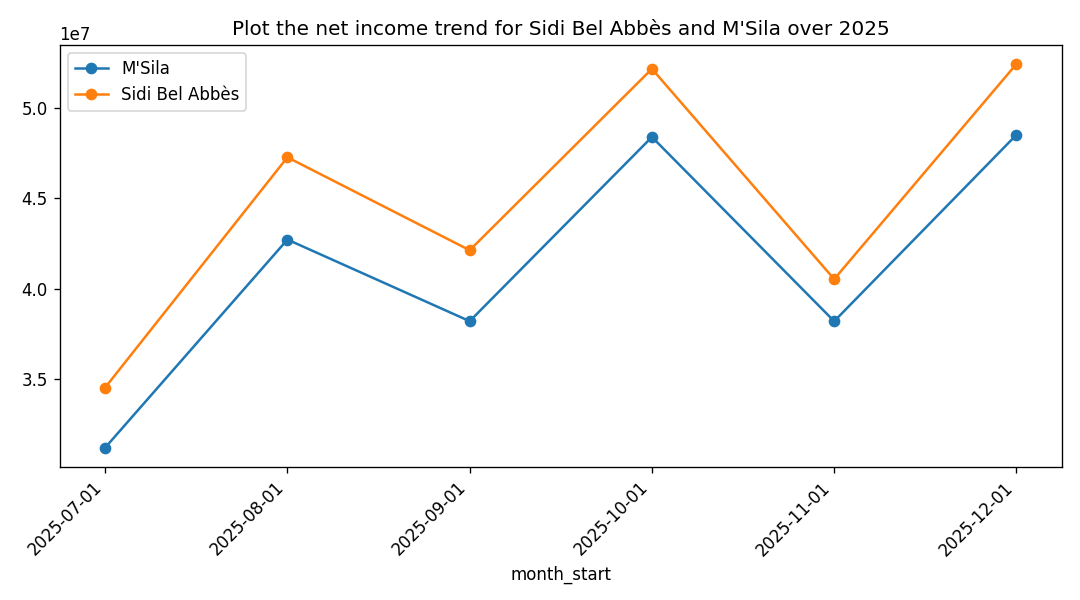

⏱  4 brain ticks 42ms · rag 0.02s · sql 16.70s · total 21.5s · VRAM 17.8 GB



In [17]:
# Chart trend, two hard wilayas — tests multi-series line + accent handling
ask("Plot the net income trend for Sidi Bel Abbès and M'Sila over 2025")

In [18]:
# opex_capex, different categories, first half of year
ask("What's the total OPEX for marketing and distribution in the first half of 2025?")


Q: What's the total OPEX for marketing and distribution in the first half of 2025?
  💭 Let me check the reference knowledge first.
     → rag  (continue 0.99)
  💭 Pulled reference knowledge (grounding 0.57).
  💭 I'll query the database for the numbers.
     → sql  (continue 0.97)
  💭 Mapped it to tables: ['opex_capex'].
  💭 Built the query: SELECT SUM(opex_marketing) + SUM(opex_distribution) AS total_opex_marketing_distribution
FROM opex_capex
WHERE strftime('%Y', week_start) = '2025'
  AND CAST(strftime('%m', week_start) AS INT) BETWEEN 1 AND 6 LIMIT 1000
  💭 Ran it — 1 row(s) back.
  💭 I have what I need — writing the answer now.
     → template  (continue 0.01)

Answer (16.3s):
Could you please specify a date within the timeframe of 2025-07-16 to 2026-04-29?
⏱  3 brain ticks 42ms · rag 0.02s · sql 13.65s · total 16.3s · VRAM 17.8 GB



In [19]:
# postpaid_kpi, hard wilaya with accent + diaeresis — tests entity resolver
# NOTE: thread="main" — cells below (follow-up, template) continue this conversation
ask("Combien d'abonnés postpaid ont migré à Aïn Témouchent le mois dernier ?")


Q: Combien d'abonnés postpaid ont migré à Aïn Témouchent le mois dernier ?
  💭 Let me check the reference knowledge first.
     → rag  (continue 0.99)
  💭 Pulled reference knowledge (grounding 0.54).
  💭 I'll query the database for the numbers.
     → sql  (continue 0.97)
  💭 Mapped it to tables: ['postpaid_kpi', 'dim_location'].
  💭 Resolved wilayas: Aïn Témouchent=28 communes.
  💭 Built the query: SELECT AVG(p.migration_rate) AS avg_migration_rate
FROM postpaid_kpi p
JOIN dim_location dl ON p.location_id = dl.location_id
WHERE dl.wilaya = 'Aïn Témouchent'
  AND p.week_start >= '2026-04-01' AND p.week_start < '2026-05-01' LIMIT 1000
  💭 Ran it — 1 row(s) back.
  💭 I have what I need — writing the answer now.
     → template  (continue 0.02)

Answer (16.6s):
Aïn Témouchent a reçu 0.9390 abonnés postpaid par an sur la période de l'an dernier.
⏱  3 brain ticks 46ms · rag 0.02s · sql 13.57s · total 16.6s · VRAM 17.8 GB



In [20]:
# Follow-up — very hard wilaya name (two words + accent), inherits postpaid + migration
ask("et pour Bordj Bou Arréridj ?")


Q: et pour Bordj Bou Arréridj ?
  💭 Let me check the reference knowledge first.
     → rag  (continue 0.95)
  💭 Pulled reference knowledge (grounding 0.38).
  💭 I'll query the database for the numbers.
     → sql  (continue 0.97)
  💭 Mapped it to tables: ['postpaid_kpi', 'dim_location'].
  💭 Resolved wilayas: Bordj Bou Arreridj=34 communes.
  💭 Built the query: SELECT AVG(p.migration_rate) AS avg_migration_rate
FROM postpaid_kpi p
JOIN dim_location dl ON p.location_id = dl.location_id
WHERE p.location_id IN (SELECT location_id FROM dim_location WHERE wilaya = 'Bordj Bou Arreridj')
  AND p.week_start >= '2026-04-01' AND p.week_start < '2026-05-01' LIMIT 1000
  💭 Ran it — 1 row(s) back.
  💭 I have what I need — writing the answer now.
     → template  (continue 0.00)

Answer (19.7s):
Bordj Bou Arréridj has an average migration rate of 0.8943.
⏱  3 brain ticks 47ms · rag 0.02s · sql 16.30s · total 19.7s · VRAM 17.8 GB



In [21]:
# Follow-up — template from last_rows (cross-turn, no SQL re-run), French
ask("Mets-le dans un rapport")


Q: Mets-le dans un rapport
  💭 Let me put this into a report.
     → template  (continue 1.00)
  💭 Report saved.
  💭 I have what I need — writing the answer now.
     → template  (continue 0.01)

Answer (0.5s):
Report generated from the previous query result.
  Report saved → /content/drive/MyDrive/LatentDjezzy/v6_output/reports/report_20260529_134901.md
⏱  2 brain ticks 46ms · rag 0.00s · sql 0.00s · total 0.5s · VRAM 16.9 GB



In [22]:
# prepaid_kpi + email — ARPU breakdown, email to CEO (mike.brown@company.com)
# Note: "finance director" in the contacts IS the test user (boukader hamza),
# so we use "CEO" here to demonstrate recipient resolution to a different person.
ask("Email the prepaid ARPU breakdown by wilaya to the CEO")


Q: Email the prepaid ARPU breakdown by wilaya to the CEO
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Pulled reference knowledge (grounding 0.54).
  💭 I'll query the database for the numbers.
     → sql  (continue 1.00)
  💭 Mapped it to tables: ['prepaid_kpi', 'dim_location'].
  💭 Built the query: SELECT dl.wilaya, AVG(p.arpu) AS avg_arpu
FROM prepaid_kpi p
JOIN dim_location dl ON p.location_id = dl.location_id
GROUP BY dl.wilaya
ORDER BY avg_arpu DESC LIMIT 1000
  💭 Ran it — 58 row(s) back.
  💭 Let me draft an email with these results.
     → email  (continue 0.98)
  💭 Drafted an email to Mike Brown.
  💭 I have what I need — writing the answer now.
     → email  (continue 0.04)

Answer (17.2s):
The prepaid ARPU breakdown by wilaya is as follows:

- In Guezzam: 3.1573
- Ghardaïa: 3.0710
- Ouargla: 3.0705
- El Meghaier: 3.0553
- El Menia: 3.0404
- Tébessa: 3.0390
- Aïn Témouchent: 3.0218
- Tamanrasset: 3.0212

These figures indicate that In Guezzam ha

**Email draft**

**To:** Mike Brown <mike.brown@company.com>  
**Subject:** Telecom analytics: Email the prepaid ARPU breakdown by wilaya to the CEO

---

Hi Mike Brown,

Here are the analytics figures you asked for.

58 rows returned:
  wilaya: In Guezzam | avg_arpu: 3.1573
  wilaya: Ghardaïa | avg_arpu: 3.0710
  wilaya: Ouargla | avg_arpu: 3.0705
  wilaya: El Meghaier | avg_arpu: 3.0553
  wilaya: El Menia | avg_arpu: 3.0404
  wilaya: Tébessa | avg_arpu: 3.0390
  wilaya: Aïn Témouchent | avg_arpu: 3.0218
  wilaya: Tamanrasset | avg_arpu: 3.0212
  ... (50 more rows)

| wilaya | avg_arpu |
| --- | --- |
| In Guezzam | 3.16 |
| Ghardaïa | 3.07 |
| Ouargla | 3.07 |
| El Meghaier | 3.06 |
| El Menia | 3.04 |
| Tébessa | 3.04 |
| Aïn Témouchent | 3.02 |
| Tamanrasset | 3.02 |
| Laghouat | 3.02 |
| Touggourt | 3.02 |
| Timimoun | 3.02 |
| Naâma | 3.01 |
| Béchar | 3.01 |
| Annaba | 3.01 |
| Ouled Djellal | 3.00 |

_(43 more rows not shown)_

Best regards,
Djezzy Voice Assistant — automated analytics assistant

---
This message was drafted automatically from the query:
  "Email the prepaid ARPU breakdown by wilaya to the CEO"
Review the figures before sending.

  Email saved → /content/drive/MyDrive/LatentDjezzy/v6_output/emails/email_20260529_134924.txt
⏱  4 brain ticks 46ms · rag 0.02s · sql 13.62s · total 17.2s · VRAM 17.8 GB



In [23]:
# Unanswerable — fake KPI with a real hard wilaya to make it tricky
ask("What is the network latency score for Ghardaïa ?")


Q: What is the network latency score for Ghardaïa ?
  💭 Let me check the reference knowledge first.
     → rag  (continue 0.96)
  💭 Pulled reference knowledge (grounding 0.41).
  💭 I'll query the database for the numbers.
     → sql  (continue 0.98)
  💭 I have what I need — writing the answer now.
     → template  (continue 0.01)

Answer (6.7s):
Could you please specify which network latency score you're looking for for Ghardaïa? Also, do you have a preferred time frame for this query?
⏱  3 brain ticks 47ms · rag 0.02s · sql 5.65s · total 6.7s · VRAM 17.5 GB




Q: Chart the postpaid churn trend for Khenchela and Tissemsilt over 2025 and email it to the operations manager
  💭 Let me check the reference knowledge first.
     → rag  (continue 1.00)
  💭 Pulled reference knowledge (grounding 0.59).
  💭 I'll query the database for the numbers.
     → sql  (continue 1.00)
  💭 Mapped it to tables: ['postpaid_kpi', 'dim_location'].
  💭 Resolved wilayas: Khenchela=21 communes, Tissemsilt=22 communes.
  💭 Built the query: SELECT 
    dl.wilaya,
    strftime('%Y-%m-01', p.week_start) AS month_start,
    AVG(p.churn_rate) AS avg_churn_rate
FROM postpaid_kpi p
JOIN dim_location dl ON p.location_id = dl.location_id
WHERE p.location_id IN (
    SELECT location_id FROM dim_location WHERE wilaya IN ('Khenchela', 'Tissemsilt')
)
    AND p.week_start >= '2025-01-01' 
    AND p.week_start < '2026-01-01'
GROUP BY dl.wilaya, month_start
ORDER BY month_start ASC LIMIT 1000
  💭 Ran it — 12 row(s) back.
  💭 The data's in — let me turn it into a chart.
     → chart  (

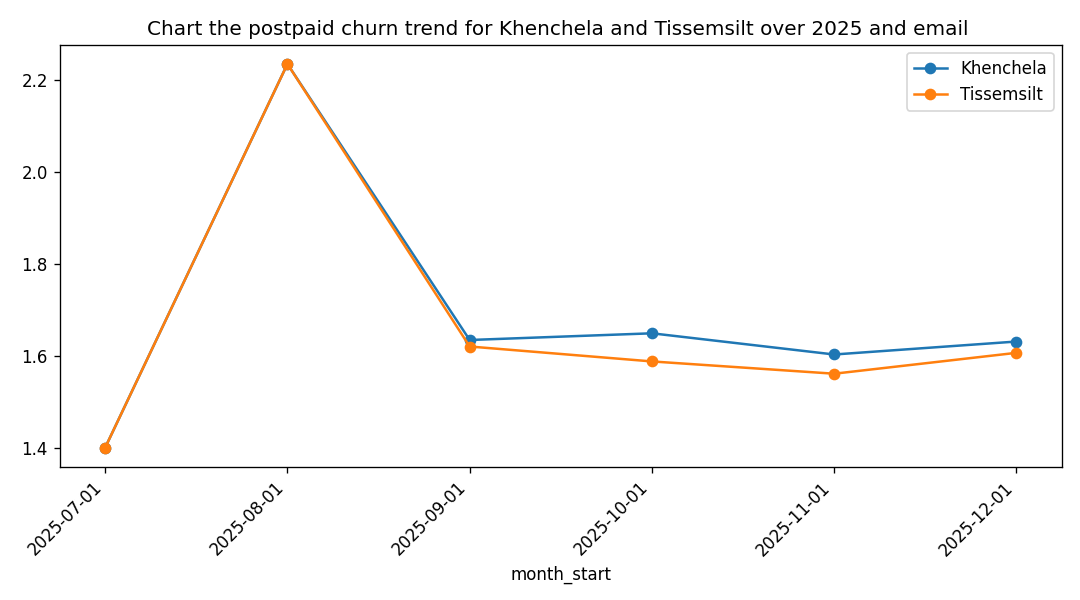

**Email draft**

**To:** Sarah Jones <sarah.jones@company.com>  
**Subject:** Telecom analytics: Chart the postpaid churn trend for Khenchela and Tissemsilt over 2025 and email it to the operations

---

Hi Sarah Jones,

Here are the analytics figures you asked for.

12 rows returned:
  wilaya: Khenchela | month_start: 2025-07-01 | avg_churn_rate: 1.4000
  wilaya: Tissemsilt | month_start: 2025-07-01 | avg_churn_rate: 1.4000
  wilaya: Khenchela | month_start: 2025-08-01 | avg_churn_rate: 2.2350
  wilaya: Tissemsilt | month_start: 2025-08-01 | avg_churn_rate: 2.2350
  wilaya: Khenchela | month_start: 2025-09-01 | avg_churn_rate: 1.6343
  wilaya: Tissemsilt | month_start: 2025-09-01 | avg_churn_rate: 1.6201
  wilaya: Khenchela | month_start: 2025-10-01 | avg_churn_rate: 1.6489
  wilaya: Tissemsilt | month_start: 2025-10-01 | avg_churn_rate: 1.5876
  ... (4 more rows)

| wilaya | month_start | avg_churn_rate |
| --- | --- | --- |
| Khenchela | 2025-07-01 | 1.40 |
| Tissemsilt | 2025-07-01 | 1.40 |
| Khenchela | 2025-08-01 | 2.24 |
| Tissemsilt | 2025-08-01 | 2.24 |
| Khenchela | 2025-09-01 | 1.63 |
| Tissemsilt | 2025-09-01 | 1.62 |
| Khenchela | 2025-10-01 | 1.65 |
| Tissemsilt | 2025-10-01 | 1.59 |
| Khenchela | 2025-11-01 | 1.60 |
| Tissemsilt | 2025-11-01 | 1.56 |
| Khenchela | 2025-12-01 | 1.63 |
| Tissemsilt | 2025-12-01 | 1.61 |

Best regards,
Djezzy Voice Assistant — automated analytics assistant

---
This message was drafted automatically from the query:
  "Chart the postpaid churn trend for Khenchela and Tissemsilt over 2025 and email it to the operations manager"
Review the figures before sending.

  Email saved → /content/drive/MyDrive/LatentDjezzy/v6_output/emails/email_20260529_135005.txt
⏱  5 brain ticks 50ms · rag 0.02s · sql 21.35s · total 27.5s · VRAM 17.8 GB



In [24]:
# Multi-capability — hard wilayas, churn trend chart + email to ops director
ask("Chart the postpaid churn trend for Khenchela and Tissemsilt over 2025 and email it to the operations manager")

In [25]:
# Times agent.graph.invoke directly (no UI polish / typewriter) so the numbers
# are the real engine cost. The brain MLP is milliseconds — the SLM dominates.
import time, torch
from v6.state import initial_state
from v6.slm import get_slm

BENCH = [
    "Salam ! C'est quoi exactement ce que tu sais faire ?",
    "C'est quoi exactement le taux de désabonnement ?",
    "Montre-moi la marge brute pour Oum El Bouaghi le trimestre dernier",
    "Which wilaya had the lowest postpaid churn rate in Q2 2025?",
    "Plot the net income trend for Sidi Bel Abbès and M'Sila over 2025",
    "Email the prepaid ARPU breakdown by wilaya to the CEO",
]

hdr = f"{'query':<46}{'intent':<11}{'steps':>6}{'brain':>9}{'sql':>9}{'total':>9}"
print(hdr)
print("-" * len(hdr))
tot = 0.0
for q in BENCH:
    t0 = time.time()
    r = agent.graph.invoke(
        initial_state(q, "bench"),
        {"configurable": {"thread_id": "bench"}, "recursion_limit": 60})
    dt = time.time() - t0
    tot += dt
    tm = r.get("timings", {})
    brain_ms = sum(v for k, v in tm.items() if k.startswith("brain"))
    sql_ms   = sum(v for k, v in tm.items() if k.startswith("sql"))
    print(f"{q[:46]:<46}{r.get('intent',''):<11}"
          f"{r.get('brain_step',0):>6}{brain_ms:>7.0f}ms"
          f"{sql_ms/1000:>8.2f}s{dt:>8.2f}s")
    get_slm().clear_thread("bench")
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

print("-" * len(hdr))
print(f"{'AVERAGE per query':<46}{'':<11}{'':>6}{'':>9}{'':>9}"
      f"{tot/len(BENCH):>8.2f}s")
if torch.cuda.is_available():
    a = torch.cuda.memory_allocated() / 1e9
    t = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"\nVRAM: {a:.2f} GB used / {t:.1f} GB total  ({t-a:.1f} GB free)")
    print("Brain overhead is the 'brain' column — a few ms per query; the "
          "SLM router+sqlgen is the cost centre.")


query                                         intent      steps    brain      sql    total
------------------------------------------------------------------------------------------
Salam ! C'est quoi exactement ce que tu sais fmeta            1     21ms    0.00s    0.03s
C'est quoi exactement le taux de désabonnementdefinition      1     34ms    0.00s    0.05s
Montre-moi la marge brute pour Oum El Bouaghi data            3     36ms   12.76s   12.82s
Which wilaya had the lowest postpaid churn ratdata            3     36ms   12.28s   12.34s
Plot the net income trend for Sidi Bel Abbès adata            4     39ms   15.70s   15.92s
Email the prepaid ARPU breakdown by wilaya to data            4     40ms   11.52s   12.30s
------------------------------------------------------------------------------------------
AVERAGE per query                                                                    8.91s

VRAM: 16.90 GB used / 23.7 GB total  (6.8 GB free)
Brain overhead is the 'brain' column —

## 📊 Benchmark — three steps

**Step 1 — Generate audio** (run once): TTS synthesises all 20 FR/EN scripts to `.wav` files on Drive.  
**Step 2 — Text benchmark**: runs the 20 queries as clean text → measures intent accuracy, SQL-exec rate, latency.  
**Step 3 — Voice benchmark** (end-to-end): feeds each `.wav` → STT → pipeline. Compares against Step 2 to show how much STT noise degrades accuracy.

Each step saves a JSON to Drive. The ANSWER REVIEW block at the end lets you mark answers right/wrong by hand.

In [26]:
# ── STEP 1: generate audio fixtures ──────────────────────────────────────────
# TTS synthesises all 20 benchmark scripts to .wav files on Drive.
# Run this ONCE; re-run only if you change bench_queries.json.
# The same files are used by Step 3 (voice benchmark) and the demo below.
import os, soundfile as sf
from IPython.display import Audio, display
from v6.benchmark import generate_audio_fixtures
from v6.config import V6Config

fixtures = generate_audio_fixtures()
print(f"\n✓ {len(fixtures)} audio fixtures saved → {V6Config.audio_dir()}")

# ── preview: one French + one English script ──────────────────────────────────
for fid in ("bench_b06", "bench_b07"):
    p = os.path.join(V6Config.audio_dir(), f"{fid}.wav")
    if os.path.isfile(p):
        wav, sr = sf.read(p)
        print(f"  ▶ {fid}")
        display(Audio(wav, rate=sr))

# ── live round-trip demo: one audio file → spoken answer ─────────────────────
print("\n— Live voice demo: audio in → STT → pipeline → spoken answer —")
ask_voice(os.path.join(V6Config.audio_dir(), "bench_b07.wav"), thread="demo")

  ♪ b01 [en] 1.7s (synth 1692ms, first chunk 1173.8ms)
  ♪ b02 [fr] 2.1s (synth 1258ms, first chunk 463.1ms)
  ♪ b03 [en] 1.9s (synth 1070ms, first chunk 461.7ms)
  ♪ b04 [fr] 1.5s (synth 875ms, first chunk 463.3ms)
  ♪ b05 [en] 1.5s (synth 851ms, first chunk 464.8ms)
  ♪ b06 [fr] 3.1s (synth 1750ms, first chunk 455.0ms)
  ♪ b07 [en] 2.2s (synth 1203ms, first chunk 461.4ms)
  ♪ b08 [fr] 2.4s (synth 1327ms, first chunk 462.9ms)
  ♪ b09 [en] 4.3s (synth 2334ms, first chunk 469.1ms)
  ♪ b10 [fr] 4.0s (synth 2109ms, first chunk 461.5ms)
  ♪ b11 [en] 3.8s (synth 2001ms, first chunk 459.5ms)
  ♪ b12 [fr] 4.9s (synth 2624ms, first chunk 459.2ms)
  ♪ b13 [en] 3.8s (synth 1994ms, first chunk 457.4ms)
  ♪ b14 [fr] 2.5s (synth 1375ms, first chunk 461.9ms)
  ♪ b15 [en] 2.5s (synth 1347ms, first chunk 459.0ms)
  ♪ b16 [fr] 3.1s (synth 1612ms, first chunk 459.2ms)
  ♪ b17 [en] 2.1s (synth 1079ms, first chunk 454.3ms)
  ♪ b18 [en] 3.3s (synth 1740ms, first chunk 458.2ms)
  ♪ b19 [fr] 1.1s (synth 666m

  ▶ bench_b07



— Live voice demo: audio in → STT → pipeline → spoken answer —
🎙  heard (en, 1140ms): What was the total revenue in Sétif last month?
🔊  speaking (en, role=analyze):
Sétif's total revenue last month was approximately 253.39 million DZD.
⏱  STT 1140ms · time-to-first-audio 1319ms · 6.4s of speech


"Sétif's total revenue last month was approximately 253.39 million DZD."

In [27]:
# ── STEP 2: text benchmark (clean baseline) ───────────────────────────────────
# Runs each query as clean text → pipeline, then polishes each answer through
# the analyst (so the ANSWER REVIEW shows the SPOKEN text — verify the number
# rounding, e.g. "24.5 million DZD", here). Grades intent / SQL-exec / latency.
from v6.benchmark import run_text_benchmark, run_voice_benchmark

print("=" * 60)
print("STEP 2 — Text pipeline benchmark (clean text input)")
print("=" * 60)
text_results = run_text_benchmark(agent)        # polish=True by default

# ── STEP 3: voice benchmark (end-to-end: .wav → STT → pipeline) ──────────────
# Transcribes each bench_*.wav (wilaya biasing + correction), feeds the
# transcript through the SAME pipeline + polisher, prints the same metrics,
# then a REGRESSIONS table: the queries where voice diverged from clean text
# (intent flipped / artifact lost / exec broke). Pass text_results so it can
# diff the two runs for you instead of eyeballing both tables.
print("\n" + "=" * 60)
print("STEP 3 — Voice pipeline benchmark (.wav → STT → pipeline)")
print("=" * 60)
voice_results = run_voice_benchmark(agent, text_rows=text_results)

STEP 2 — Text pipeline benchmark (clean text input)
  · running b01 [en] Hi there, good to meet you.
  · running b02 [fr] Salam, comment vas-tu aujourd'hui ?
  · running b03 [en] What kind of questions can I ask you?
  · running b04 [fr] C'est quoi exactement l'ARPU ?
  · running b05 [en] What does the churn rate mean?
  · running b06 [fr] Montre-moi la marge brute pour Oran le trimestre d
  · running b07 [en] What was the total revenue in Setif last month?
  · running b08 [fr] Compare le revenu net entre Alger et Oran.
  · running b09 [en] Which wilaya had the lowest postpaid churn rate in
  · running b10 [fr] Trace la tendance du revenu net pour Tlemcen sur 2
  · running b11 [en] Plot the prepaid ARPU trend for Annaba over 2025.
  · running b12 [fr] Envoie le détail de l'ARPU prépayé par wilaya au d
  · running b13 [en] Email the postpaid churn by wilaya to the operatio
  · running b14 [fr] Mets le revenu total par wilaya dans un rapport.
  · running b15 [en] Put the OPEX breakdown f

In [28]:
import torch
if torch.cuda.is_available():
    alloc  = torch.cuda.memory_allocated() / 1e9
    reserv = torch.cuda.memory_reserved()  / 1e9
    total  = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU  allocated: {alloc:.2f} GB")
    print(f"GPU  reserved:  {reserv:.2f} GB")
    print(f"GPU  total:     {total:.2f} GB")

GPU  allocated: 16.90 GB
GPU  reserved:  16.92 GB
GPU  total:     23.66 GB


In [29]:
# Direct streaming — bypasses the graph, useful for quick SLM checks.
from v6.slm import get_slm

slm = get_slm()
messages = [
    {"role": "system", "content": "You are a helpful telecom analyst."},
    {"role": "user",   "content": "List the top 3 KPIs for a telecom operator."},
]
print("Streaming response:")
for token in slm.stream_generate(messages, max_new_tokens=256):
    print(token, end="", flush=True)
print()

Streaming response:
Certainly! For a telecom operator, the top 3 Key Performance Indicators (KPIs) are critical to measuring service quality, customer satisfaction, and operational efficiency. These KPIs are:

1. **Network Availability and Uptime**  
   - Measures the percentage of time the network is operational and accessible to customers.  
   - Typically expressed as a percentage (e.g., 99.9% uptime).  
   - Importance: High availability ensures reliable connectivity, which directly impacts customer experience and trust.

2. **Customer Satisfaction (CSAT) or Net Promoter Score (NPS)**  
   - CSAT measures how satisfied customers are with services (e.g., call quality, speed, support).  
   - NPS gauges customer loyalty and willingness to recommend the operator.  
   - Importance: Reflects the quality of service delivery and helps identify areas for improvement in customer experience.

3. **Average Revenue Per User (ARPU)**  
   - Measures the average revenue generated per customer. 